<a href="https://colab.research.google.com/github/ora404/Syntecxhub_Data_Science/blob/main/Syntecxhub_Project1_Sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**PROJECT 1**
## **SALES ANALYTICS**

In [4]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

sales = pd.read_csv('shopping_trends_updated.csv')
sales.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [5]:
sales.tail()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly
3899,3900,52,Female,Handbag,Accessories,81,California,M,Beige,Spring,3.1,No,Store Pickup,No,No,33,Venmo,Quarterly


In [8]:
sales.shape

(3900, 18)

**CLEANING OF THE DATA**

The dataset was checked to verify the data types, identify any missing values, and detect duplicate records to ensure the data was accurate and ready for analysis.


In [9]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [10]:
sales.isnull().sum()

,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [12]:
sales.duplicated().sum()

np.int64(0)

**DATA EXPLORATION AND VISUALIZATION**


In [13]:
sales.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


**QUESTION 1**

The frequency of each payment method was calculated to identify the most popular payment method, and the results were presented using an appropriate visualization.

In [14]:
sales.groupby('Payment Method')['Payment Method'].count().sort_values(ascending=False)

,Payment Method
Payment Method,
PayPal,677
Credit Card,671
Cash,670
Debit Card,636
Venmo,634
Bank Transfer,612


<Axes: xlabel='count', ylabel='Payment Method'>

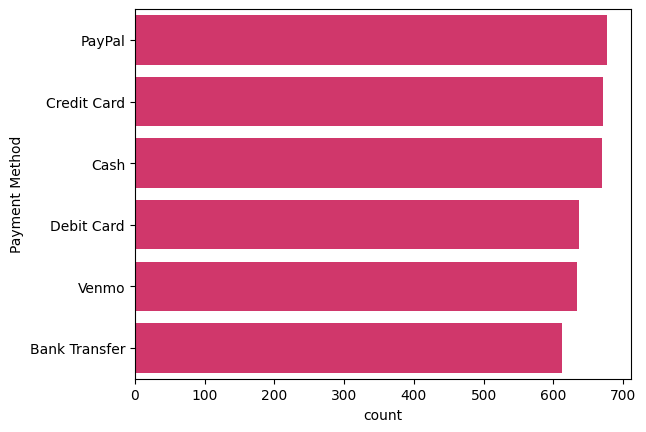

In [26]:
base_color = sb.color_palette()[0]

method = sales['Payment Method'].value_counts().index
sb.countplot(data = sales, y = 'Payment Method', color = '#E91E63', order = method)

**QUESTION 2**

The frequency of each purchased item was calculated to determine the most popular item, and the findings were visualized using a chart.

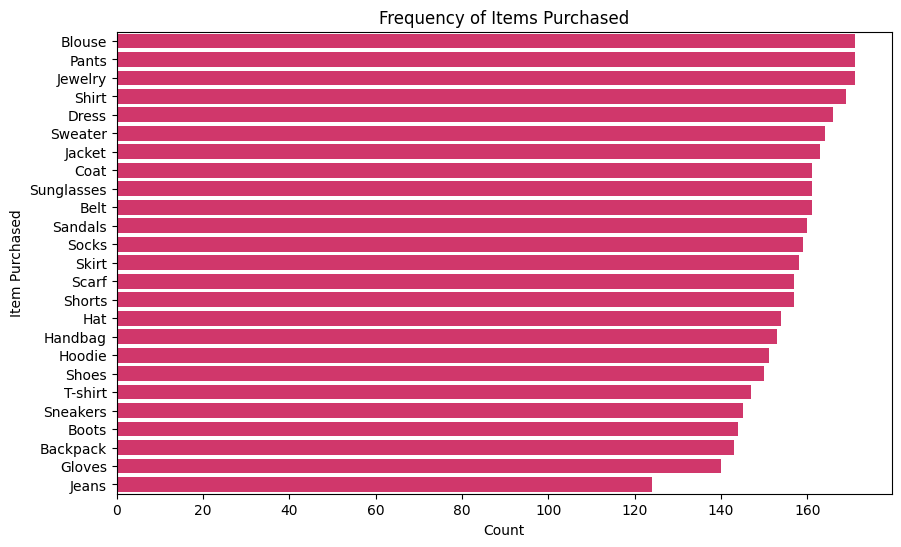

In [28]:
item_counts = sales.groupby('Item Purchased')['Item Purchased'].count().sort_values(ascending=False)
item_counts

plt.figure(figsize=(10,6))
item_order = sales['Item Purchased'].value_counts().index
sb.countplot(data=sales, y='Item Purchased', color='#E91E63', order=item_order)
plt.title('Frequency of Items Purchased')
plt.xlabel('Count')
plt.ylabel('Item Purchased')
plt.show()

**QUESTION 3**

The dataset was filtered to include only female customers, after which the most frequently purchased item was identified.

In [18]:
sales.Gender.unique()

array(['Male', 'Female'], dtype=object)

In [19]:
sales[(sales['Gender']=='Female')].groupby('Item Purchased')['Item Purchased'].count().sort_values(ascending=False).head(1)

,Item Purchased
Item Purchased,
Blouse,66


**QUESTION 4**

The total sales for each location were calculated to determine which locations generated the highest sales, and the results were visualized using a chart.

<Axes: xlabel='count', ylabel='Location'>

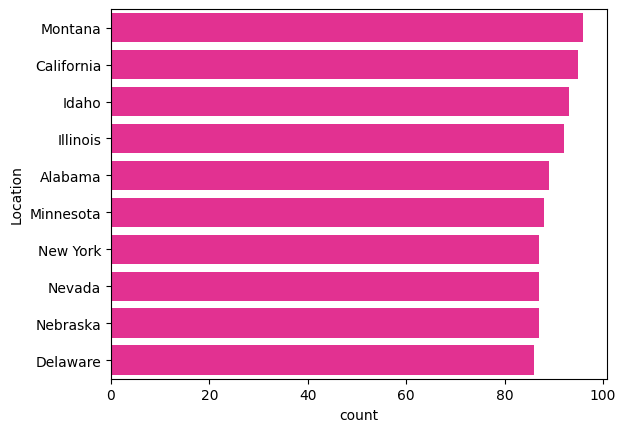

In [25]:
location = sales['Location'].value_counts().head(10).index
sb.countplot(data = sales, y = 'Location', color = '#FF1493', order = location)

**QUESTION 5**

The core KPIs: Total Revenue, Total Orders, and Average Order Value were computed to summarize overall sales performance.

In [29]:
total_revenue = sales['Purchase Amount (USD)'].sum()
total_orders = sales.shape[0]
average_order_value = total_revenue / total_orders

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ${average_order_value:,.2f}")

Total Revenue: $233,081.00
Total Orders: 3,900
Average Order Value: $59.76


**QUESTION 6**

Total revenue by item was calculated (rather than raw frequency) to identify the top products by sales dollars.

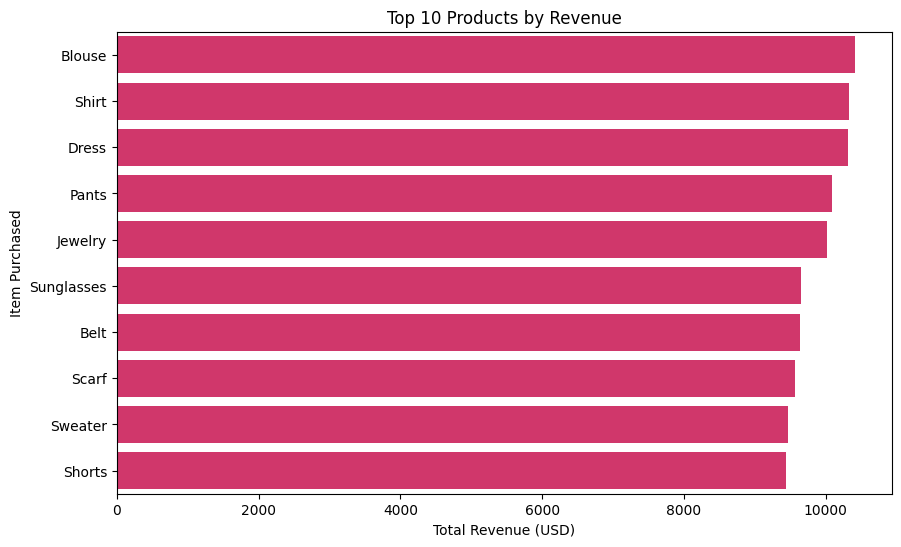

In [31]:
item_revenue = sales.groupby('Item Purchased')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
item_revenue.head(10)

plt.figure(figsize=(10,6))
top_items = item_revenue.head(10).index
sb.barplot(data=sales, y='Item Purchased', x='Purchase Amount (USD)',
           color='#E91E63', order=top_items, estimator=sum, errorbar=None)
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Item Purchased')
plt.show()

**QUESTION 7**

Revenue was grouped by category to see which product categories contribute most to sales.

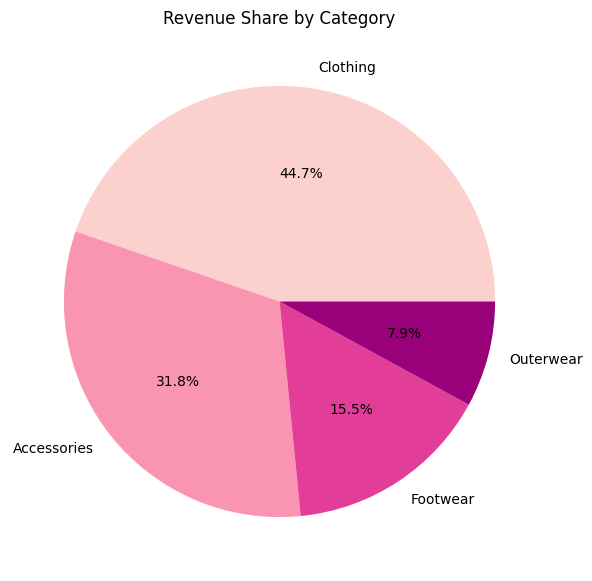

In [32]:
category_revenue = sales.groupby('Category')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
category_revenue

plt.figure(figsize=(7,7))
plt.pie(category_revenue, labels=category_revenue.index, autopct='%1.1f%%',
        colors=sb.color_palette('RdPu', len(category_revenue)))
plt.title('Revenue Share by Category')
plt.show()

**QUESTION 8**

Total revenue by location was calculated (rather than order count) to determine the top-grossing states.

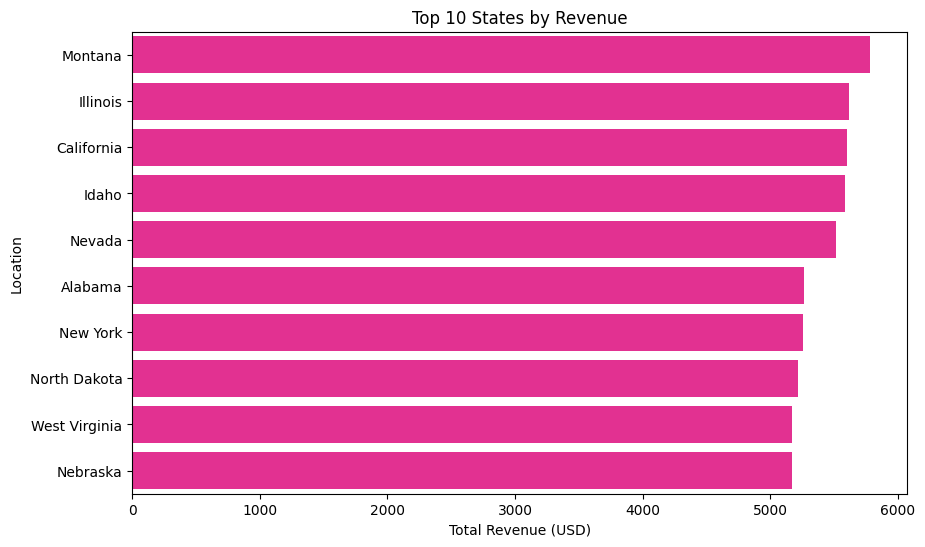

In [33]:
location_revenue = sales.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False)
top_locations = location_revenue.head(10)
top_locations

plt.figure(figsize=(10,6))
sb.barplot(data=sales, y='Location', x='Purchase Amount (USD)',
           color='#FF1493', order=top_locations.index, estimator=sum, errorbar=None)
plt.title('Top 10 States by Revenue')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Location')
plt.show()

**QUESTION 9**

Revenue was grouped by season to identify seasonal sales trends.

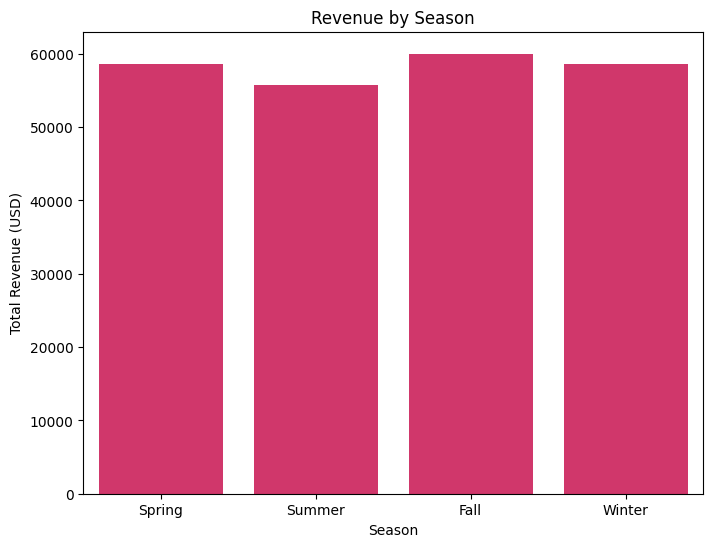

In [34]:
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_revenue = sales.groupby('Season')['Purchase Amount (USD)'].sum().reindex(season_order)
season_revenue

plt.figure(figsize=(8,6))
sb.barplot(x=season_revenue.index, y=season_revenue.values, color='#E91E63', order=season_order)
plt.title('Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Total Revenue (USD)')
plt.show()

**QUESTION 10**

Average order value was compared between orders with and without a discount applied.

In [35]:
discount_aov = sales.groupby('Discount Applied')['Purchase Amount (USD)'].mean()
discount_aov

,Purchase Amount (USD)
Discount Applied,
No,60.130454
Yes,59.279070


### **Key Insights & Recommendations**

- Clothing (~$104K) and Accessories (~$74K) are the top revenue categories. Prioritize inventory and marketing here.
- Fall is the strongest season (~$60K); Summer is the weakest (~$56K). Plan fall promotions and consider targeted summer discounts.
- Montana, Illinois, and California are the top-grossing states. Worth extra regional marketing investment.
- Average order value is nearly identical with or without a discount applied. Current discounting isn't meaningfully increasing basket size.